In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc
from collections import defaultdict
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import precision_recall_curve, auc
import torch
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, GATv2Conv
import torch.nn as nn
import torch.nn.functional as F

print(f"PyTorch : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch : 2.11.0+cpu
CUDA disponible : False


In [2]:

features_users = pd.read_csv('features_v3.csv')
df_users = pd.read_parquet('cert_dataset/users.parquet')
df_users = df_users.rename(columns={'user_id': 'user'})


df = features_users.merge(df_users[['user', 'supervisor']], on='user', how='left')
df.reset_index(drop=True, inplace=True)
df['node_id'] = df.index


meta_cols = ['user', 'supervisor', 'node_id']
feature_cols = [c for c in df.columns if c not in meta_cols]

print(f"Nœuds      : {len(df)}")
print(f"Features   : {len(feature_cols)}")
print(f"\nDataset shape : {df.shape}")
df.head()

Nœuds      : 4000
Features   : 53

Dataset shape : (4000, 56)


,user,email_external_ratio,email_suspicious_content_ratio,email_bcc_email_ratio,email_external_email_with_attachment_ratio,email_after_hours_or_weekend_ratio,email_max_zscore_emails,email_avg_emails_per_week,email_avg_size_sent_email,email_zscore_last_month,...,http_last_month_zscore,http_max_zscore_activity,http_sus_domain_ratio,http_unique_domains,http_job_search_score,users_post_departure_activity,users_pre_departure_ratio,users_activity_not_main_pc_ratio,supervisor,node_id
0,AAB0162,0.307374,0.014940,0.0,0.051176,0.000000,0.0,42.513514,1.994349e+05,-0.871931,...,0.0,0.0,0.0318,126,0.0699,0.0,0.000000,0.0,Jeanette Macey Simpson,0
1,AAB0398,0.383626,0.003674,0.0,0.118079,0.056416,0.0,51.500000,3.568791e+05,-0.095175,...,0.0,0.0,0.0308,248,0.0133,0.0,0.000000,0.0,Deborah Madaline Horton,1
2,AAC0610,0.363118,0.009506,0.0,0.132129,0.000000,0.0,14.216216,8.273392e+05,0.315768,...,0.0,0.0,0.1031,200,0.0189,0.0,0.001404,0.0,Ann Tamekah Daniels,2
3,AAC0668,0.350562,0.007705,0.0,0.070305,0.000000,0.0,42.094595,4.068177e+05,0.439913,...,0.0,0.0,0.0342,175,0.0548,0.0,0.000000,0.0,Grace Jasmine Gamble,3
4,AAC3270,0.258721,0.000000,0.0,0.139535,0.000000,0.0,4.648649,1.333953e+06,0.901975,...,0.0,0.0,0.0000,55,0.0045,0.0,0.000000,0.0,Quincy Guy Shannon,4


In [3]:

scaler = StandardScaler()
X = scaler.fit_transform(df[feature_cols].fillna(0).values)
print(f"X shape : {X.shape}")
print(f"X statistics - mean: {X.mean():.4f}, std: {X.std():.4f}")

X shape : (4000, 53)
X statistics - mean: -0.0000, std: 1.0000


In [4]:

edges_peer = []
df_with_sup = df[df['supervisor'].notna()]
for sup, group in df_with_sup.groupby('supervisor'):
    node_ids = group['node_id'].values
    if len(node_ids) < 2:
        continue
    for i in range(len(node_ids)):
        for j in range(i + 1, len(node_ids)):
            edges_peer += [(node_ids[i], node_ids[j]), (node_ids[j], node_ids[i])]

edges_peer = np.array(edges_peer).T
print(f"Arêtes peers (même superviseur) : {edges_peer.shape[1]:,}")

Arêtes peers (même superviseur) : 76,018


In [5]:

k = 5
nn_model = NearestNeighbors(n_neighbors=k + 1, metric='cosine')
nn_model.fit(X)
_, neighbor_positions = nn_model.kneighbors(X)

edges_set = set()
node_ids_arr = df['node_id'].values
for i in range(len(node_ids_arr)):
    src = node_ids_arr[i]
    for pos in neighbor_positions[i, 1:]:
        dst = node_ids_arr[pos]
        edges_set.add((src, dst))
        edges_set.add((dst, src))
edges_knn = np.array(list(edges_set)).T
print(f"Arêtes kNN (k={k}, cosine)      : {edges_knn.shape[1]:,}")

Arêtes kNN (k=5, cosine)      : 28,738


In [6]:

user2node = dict(zip(df['user'], df['node_id']))
edges_hier = []
for _, row in df.iterrows():
    if pd.notna(row['supervisor']) and row['supervisor'] in user2node:
        emp_node = row['node_id']
        sup_node = user2node[row['supervisor']]
        edges_hier += [(emp_node, sup_node), (sup_node, emp_node)]

if len(edges_hier) > 0:
    edges_hier = np.array(edges_hier).T
    print(f"Arêtes hiérarchie (emp -> sup)  : {edges_hier.shape[1]:,}")
else:
    edges_hier = None
    print("Arêtes hiérarchie               : 0 (superviseurs absents du dataset)")

Arêtes hiérarchie               : 0 (superviseurs absents du dataset)


In [7]:

edge_index_peer = torch.tensor(edges_peer, dtype=torch.long)
edge_index_knn  = torch.tensor(edges_knn,  dtype=torch.long)


edge_parts = [edge_index_peer, edge_index_knn]
type_parts = [
    torch.zeros(edge_index_peer.shape[1], dtype=torch.long),
    torch.ones(edge_index_knn.shape[1],   dtype=torch.long),
]


if edges_hier is not None:
    edge_index_hier = torch.tensor(edges_hier, dtype=torch.long)
    edge_parts.append(edge_index_hier)
    type_parts.append(torch.full((edge_index_hier.shape[1],), 2, dtype=torch.long))
    num_relations = 3
else:
    num_relations = 2


edge_index = torch.cat(edge_parts, dim=1)
edge_type  = torch.cat(type_parts)
x = torch.tensor(X, dtype=torch.float)


data = Data(x=x, edge_index=edge_index, edge_type=edge_type)
data.num_relations = num_relations

print(data)
print(f"\nRelations : {num_relations}")
for r in range(num_relations):
    print(f"  type {r} : {(edge_type==r).sum().item():,} arêtes")

Data(x=[4000, 53], edge_index=[2, 104756], edge_type=[104756], num_relations=2)

Relations : 2
  type 0 : 76,018 arêtes
  type 1 : 28,738 arêtes


In [8]:
class GATAutoencoderImproved(nn.Module):
    """
    Improved GAT-based Autoencoder with:
    - Multi-head attention mechanism
    - Multiple GAT layers for deep graph learning
    - Layer normalization for training stability
    - Separate attention heads per relation type
    - Dense decoder with skip connections
    """
    def __init__(self, in_channels, hidden1, hidden2, out_channels, 
                 num_relations=3, num_heads=8, dropout=0.3, 
                 concat_heads=True):
        super().__init__()

        self.num_relations = num_relations
        self.num_heads = num_heads
        self.concat_heads = concat_heads
        
        
        self.gat_layers_1 = nn.ModuleList([
            GATv2Conv(in_channels, hidden1 // num_heads, heads=num_heads, 
                     dropout=dropout, concat=concat_heads, edge_dim=1)
            for _ in range(num_relations)
        ])
        self.bn1 = nn.BatchNorm1d(hidden1)
        self.ln1 = nn.LayerNorm(hidden1)
        
      
        self.gat_layers_2 = nn.ModuleList([
            GATv2Conv(hidden1, hidden2 // num_heads, heads=num_heads,
                     dropout=dropout, concat=concat_heads, edge_dim=1)
            for _ in range(num_relations)
        ])
        self.bn2 = nn.BatchNorm1d(hidden2)
        self.ln2 = nn.LayerNorm(hidden2)
        
       
        self.gat_layers_3 = nn.ModuleList([
            GATv2Conv(hidden2, out_channels // num_heads, heads=num_heads,
                     dropout=dropout, concat=concat_heads, edge_dim=1)
            for _ in range(num_relations)
        ])
        self.bn3 = nn.BatchNorm1d(out_channels)
        self.ln3 = nn.LayerNorm(out_channels)
        
        
        self.skip_proj_1 = nn.Linear(hidden1, out_channels, bias=False)
        self.skip_proj_2 = nn.Linear(hidden2, out_channels, bias=False)
        
       
        self.dropout = nn.Dropout(p=dropout)
        
        
        self.decoder = nn.Sequential(
            nn.Linear(out_channels, hidden2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden2),
            nn.Dropout(p=dropout),
            nn.Linear(hidden2, hidden1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden1),
            nn.Dropout(p=dropout),
            nn.Linear(hidden1, in_channels),
        )

    def encode(self, x, edge_index, edge_type):
        """
        Encode features through GAT layers.
        Process each relation type separately, then aggregate.
        """
       
        h1_list = []
        for r in range(self.num_relations):
            mask = edge_type == r
            if mask.sum() > 0:
                edge_index_r = edge_index[:, mask]
                edge_attr = torch.ones(edge_index_r.shape[1], 1, 
                                       device=x.device, dtype=x.dtype)
                h1_r = self.gat_layers_1[r](x, edge_index_r, edge_attr=edge_attr)
                h1_list.append(h1_r)
        
      
        h1 = torch.stack(h1_list, dim=0).mean(dim=0)
        h1 = self.bn1(h1)
        h1 = self.ln1(h1)
        h1 = F.relu(h1)
        h1 = self.dropout(h1)
        
        
        h2_list = []
        for r in range(self.num_relations):
            mask = edge_type == r
            if mask.sum() > 0:
                edge_index_r = edge_index[:, mask]
                edge_attr = torch.ones(edge_index_r.shape[1], 1,
                                       device=x.device, dtype=x.dtype)
                h2_r = self.gat_layers_2[r](h1, edge_index_r, edge_attr=edge_attr)
                h2_list.append(h2_r)
        
        h2 = torch.stack(h2_list, dim=0).mean(dim=0)
        h2 = self.bn2(h2)
        h2 = self.ln2(h2)
        h2 = F.relu(h2)
        h2 = self.dropout(h2)
        
       
        h3_list = []
        for r in range(self.num_relations):
            mask = edge_type == r
            if mask.sum() > 0:
                edge_index_r = edge_index[:, mask]
                edge_attr = torch.ones(edge_index_r.shape[1], 1,
                                       device=x.device, dtype=x.dtype)
                h3_r = self.gat_layers_3[r](h2, edge_index_r, edge_attr=edge_attr)
                h3_list.append(h3_r)
        
        h3 = torch.stack(h3_list, dim=0).mean(dim=0)
        h3 = self.bn3(h3)
        h3 = self.ln3(h3)
        
        
        z = h3 + 0.3 * self.skip_proj_1(h1) + 0.1 * self.skip_proj_2(h2)
        return z

    def decode_features(self, z):
        """Decode embeddings back to feature space."""
        return self.decoder(z)

    def decode_links(self, z, edge_index):
        """Compute link prediction scores (dot product similarity)."""
        src, dst = edge_index
        return (z[src] * z[dst]).sum(dim=-1)

    def forward(self, x, edge_index, edge_type):
        z = self.encode(x, edge_index, edge_type)
        x_hat = self.decode_features(z)
        return z, x_hat


print("Model architecture defined.")

Model architecture defined.


In [14]:
class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance.
    Focuses on hard negatives/positives by down-weighting easy examples.
    
    FL(pt) = -alpha * (1 - pt)^gamma * log(pt)
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        """
        Args:
            logits: Model output scores (can be unbounded)
            targets: Binary targets (0 or 1)
        """
       
        p = torch.sigmoid(logits)
        p = torch.clamp(p, min=1e-7, max=1 - 1e-7)
        
       
        ce_loss = F.binary_cross_entropy(p, targets, reduction='none')
        focal_weight = torch.where(targets == 1, (1 - p) ** self.gamma, p ** self.gamma)
        loss = self.alpha * focal_weight * ce_loss
        
        return loss.mean()


def contrastive_loss(z, edge_index, num_nodes, n_neg=512, margin=1.0):
    """
    Hinge contrastive loss on normalized embeddings.
    Pulls positive pairs closer, pushes negative pairs apart.
    """
    z_norm = F.normalize(z, dim=-1)
    
    
    pos_idx = torch.randint(0, edge_index.shape[1], (n_neg,), device=z.device)
    src_p, dst_p = edge_index[:, pos_idx]
    sim_pos = (z_norm[src_p] * z_norm[dst_p]).sum(dim=-1)  
    loss_pos = (1 - sim_pos).clamp(min=0).mean()
    
   
    src_n = torch.randint(0, num_nodes, (n_neg,), device=z.device)
    dst_n = torch.randint(0, num_nodes, (n_neg,), device=z.device)
    sim_neg = (z_norm[src_n] * z_norm[dst_n]).sum(dim=-1)
    loss_neg = (sim_neg - (-margin)).clamp(min=0).mean()
    
    return loss_pos + loss_neg

In [15]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")


model = GATAutoencoderImproved(
    in_channels=X.shape[1],
    hidden1=256,        
    hidden2=128,       
    out_channels=48,    
    num_relations=num_relations,
    num_heads=8,      
    dropout=0.35,       
    concat_heads=True
).to(device)

data = data.to(device)


n_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Paramètres     : {n_params:,}")
print(f"Paramètres entraînables : {trainable_params:,}")
print(f"\nArchitecture :")
print(model)

Device : cpu

Total Paramètres     : 288,085
Paramètres entraînables : 288,085

Architecture :
GATAutoencoderImproved(
  (gat_layers_1): ModuleList(
    (0-1): 2 x GATv2Conv(53, 32, heads=8)
  )
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (gat_layers_2): ModuleList(
    (0-1): 2 x GATv2Conv(256, 16, heads=8)
  )
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (gat_layers_3): ModuleList(
    (0-1): 2 x GATv2Conv(128, 6, heads=8)
  )
  (bn3): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (ln3): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
  (skip_proj_1): Linear(in_features=256, out_features=48, bias=False)
  (skip_proj_2): Linear(in_features=128, out_features=48, bias=False)
  (dropout): Dropout(p=0.35, inplace=False)
  (decoder)

In [16]:

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4, betas=(0.9, 0.999))


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.7, patience=200, min_lr=1e-6
)


focal_loss_fn = FocalLoss(alpha=0.25, gamma=2.0)


num_epochs      = 8000
num_neg_samples = 2048
num_pos_edges   = data.edge_index.shape[1]
num_nodes       = data.num_nodes

alpha = 0.35   
beta  = 0.40  
gamma = 0.25  

print(f"Epochs : {num_epochs}")
print(f"Batch size (neg samples) : {num_neg_samples}")
print(f"Loss weights : α={alpha} β={beta} γ={gamma}")
print(f"Optimizer : AdamW with weight decay")
print(f"Scheduler : ReduceLROnPlateau")

Epochs : 8000
Batch size (neg samples) : 2048
Loss weights : α=0.35 β=0.4 γ=0.25
Optimizer : AdamW with weight decay
Scheduler : ReduceLROnPlateau


In [17]:
model.train()
losses_history = {
    'total': [], 
    'recon': [], 
    'link': [], 
    'contrastive': [],
    'learning_rate': []
}

best_loss = float('inf')
patience_counter = 0
max_patience = 500

print("Starting training...\n")

for epoch in range(num_epochs):
    optimizer.zero_grad()

    
    z, x_hat = model(data.x, data.edge_index, data.edge_type)

   
    loss_recon = F.mse_loss(x_hat, data.x)

   
    pos_idx  = torch.randint(0, num_pos_edges, (num_neg_samples,), device=device)
    pos_edges = data.edge_index[:, pos_idx]
    neg_src  = torch.randint(0, num_nodes, (num_neg_samples,), device=device)
    neg_dst  = torch.randint(0, num_nodes, (num_neg_samples,), device=device)
    neg_edges = torch.stack([neg_src, neg_dst], dim=0)

    pos_scores = model.decode_links(z, pos_edges)
    neg_scores = model.decode_links(z, neg_edges)
    
   
    loss_link = focal_loss_fn(pos_scores, torch.ones_like(pos_scores)) + \
                focal_loss_fn(neg_scores, torch.zeros_like(neg_scores))

   
    loss_cont = contrastive_loss(z, data.edge_index, num_nodes, n_neg=num_neg_samples)

  
    loss = alpha * loss_recon + beta * loss_link + gamma * loss_cont


    loss.backward()
    

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    optimizer.step()
    scheduler.step(loss)

  
    losses_history['total'].append(loss.item())
    losses_history['recon'].append(loss_recon.item())
    losses_history['link'].append(loss_link.item())
    losses_history['contrastive'].append(loss_cont.item())
    losses_history['learning_rate'].append(optimizer.param_groups[0]['lr'])

   
    if loss.item() < best_loss:
        best_loss = loss.item()
        patience_counter = 0
    else:
        patience_counter += 1

    # Print progress
    if epoch % 500 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:5d} | Total: {loss.item():.4f} | "
              f"Recon: {loss_recon.item():.4f} | Link: {loss_link.item():.4f} | "
              f"Cont: {loss_cont.item():.4f} | LR: {lr_now:.6f}")

print(f"\nEntraînement terminé après {epoch + 1} epochs.")
print(f"Meilleure loss : {best_loss:.4f}")

Starting training...



c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\optim\lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  current = float(metrics)


Epoch     0 | Total: 1.2869 | Recon: 1.5317 | Link: 0.8702 | Cont: 1.6107 | LR: 0.000500
Epoch   500 | Total: 0.5505 | Recon: 0.3639 | Link: 0.1556 | Cont: 1.4435 | LR: 0.000500
Epoch  1000 | Total: 0.4852 | Recon: 0.2956 | Link: 0.1165 | Cont: 1.3405 | LR: 0.000500
Epoch  1500 | Total: 0.4473 | Recon: 0.2579 | Link: 0.0967 | Cont: 1.2733 | LR: 0.000500
Epoch  2000 | Total: 0.4180 | Recon: 0.2376 | Link: 0.0777 | Cont: 1.2149 | LR: 0.000500
Epoch  2500 | Total: 0.3981 | Recon: 0.2177 | Link: 0.0744 | Cont: 1.1685 | LR: 0.000500
Epoch  3000 | Total: 0.3901 | Recon: 0.2064 | Link: 0.0690 | Cont: 1.1610 | LR: 0.000500
Epoch  3500 | Total: 0.3766 | Recon: 0.1896 | Link: 0.0696 | Cont: 1.1294 | LR: 0.000350
Epoch  4000 | Total: 0.3756 | Recon: 0.1860 | Link: 0.0677 | Cont: 1.1336 | LR: 0.000350
Epoch  4500 | Total: 0.3741 | Recon: 0.1836 | Link: 0.0666 | Cont: 1.1326 | LR: 0.000171
Epoch  5000 | Total: 0.3650 | Recon: 0.1758 | Link: 0.0685 | Cont: 1.1043 | LR: 0.000059
Epoch  5500 | Total: 

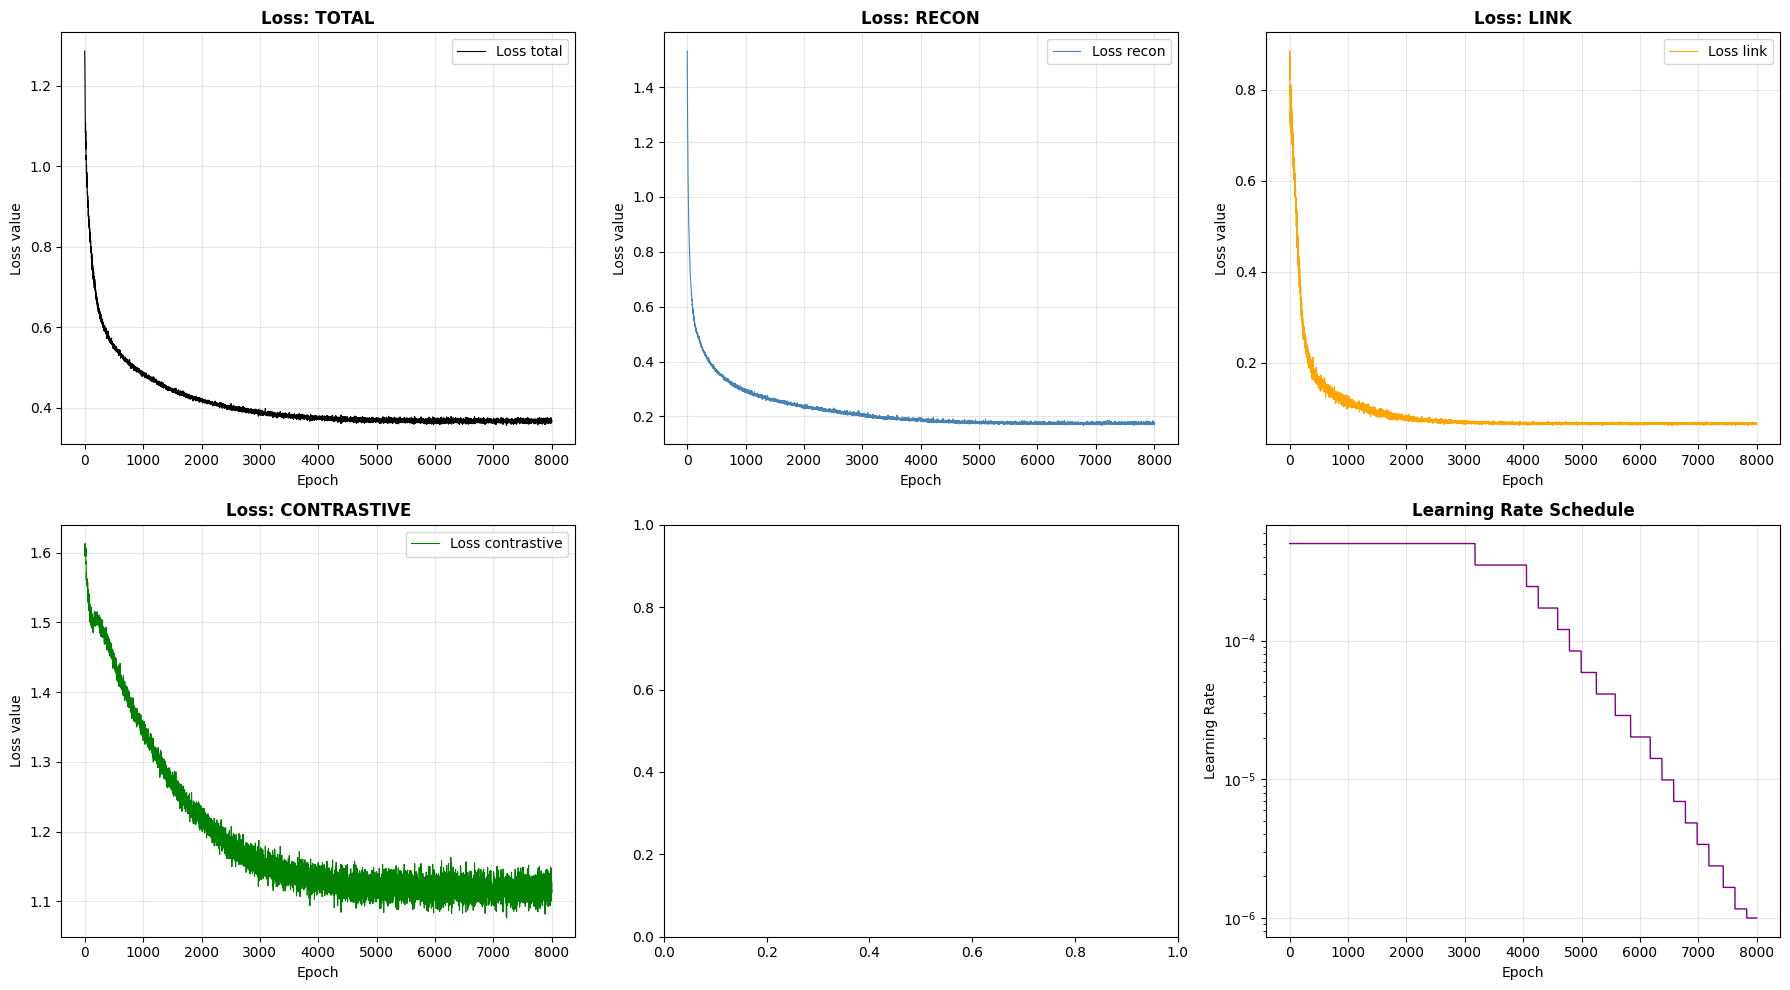

Loss curves saved to 'losses_improved.png'


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

loss_names = ['total', 'recon', 'link', 'contrastive']
colors = ['black', 'steelblue', 'orange', 'green']

for idx, (name, color) in enumerate(zip(loss_names, colors)):
    ax = axes[idx // 3, idx % 3]
    ax.plot(losses_history[name], color=color, linewidth=0.8, label=f'Loss {name}')
    ax.set_title(f'Loss: {name.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss value')
    ax.grid(alpha=0.3)
    ax.legend()


ax = axes[1, 2]
ax.plot(losses_history['learning_rate'], color='purple', linewidth=1)
ax.set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_yscale('log')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('losses_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss curves saved to 'losses_improved.png'")

In [19]:

model.eval()
with torch.no_grad():
    z_final, x_hat_final = model(data.x, data.edge_index, data.edge_type)

Z = z_final.cpu().numpy()
X_hat = x_hat_final.cpu().numpy()
X_orig = data.x.cpu().numpy()


recon_error = np.mean((X_orig - X_hat) ** 2, axis=1)

print(f"Embeddings Z          : {Z.shape}")
print(f"Reconstruction Error  : min={recon_error.min():.4f}, max={recon_error.max():.4f}, mean={recon_error.mean():.4f}")
print(f"\nEmbedding Statistics :")
print(f"  Mean: {Z.mean():.4f}, Std: {Z.std():.4f}")
print(f"  Min: {Z.min():.4f}, Max: {Z.max():.4f}")

Embeddings Z          : (4000, 48)
Reconstruction Error  : min=0.0017, max=0.9235, mean=0.0700

Embedding Statistics :
  Mean: -0.0004, Std: 0.1419
  Min: -1.1960, Max: 0.8909


In [20]:
from sklearn.preprocessing import MinMaxScaler


mm = MinMaxScaler()


iforest = IsolationForest(
    n_estimators=5000, 
    max_samples=1024,
    contamination='auto', 
    random_state=42, 
    n_jobs=-1
)
iforest.fit(Z)
score_if = -iforest.score_samples(Z)
score_if_norm = mm.fit_transform(score_if.reshape(-1, 1)).ravel()


score_recon_norm = mm.fit_transform(recon_error.reshape(-1, 1)).ravel()

lof = LocalOutlierFactor(
    n_neighbors=20, 
    novelty=True, 
    contamination='auto', 
    n_jobs=-1
)
lof.fit(Z)
score_lof = -lof.score_samples(Z)
score_lof_norm = mm.fit_transform(score_lof.reshape(-1, 1)).ravel()


w1, w2, w3 = 0.45, 0.30, 0.25
anomaly_scores = w1 * score_if_norm + w2 * score_recon_norm + w3 * score_lof_norm

print(f"Anomaly Score Statistics:")
print(f"  Min: {anomaly_scores.min():.4f}")
print(f"  Max: {anomaly_scores.max():.4f}")
print(f"  Mean: {anomaly_scores.mean():.4f}")
print(f"  Std: {anomaly_scores.std():.4f}")
print(f"\nComponent Weights:")
print(f"  IsolationForest (global isolation):     {w1:.2f}")
print(f"  Reconstruction Error (behavior fit):    {w2:.2f}")
print(f"  Local Outlier Factor (local density):   {w3:.2f}")

Anomaly Score Statistics:
  Min: 0.0054
  Max: 0.5302
  Mean: 0.1449
  Std: 0.0856

Component Weights:
  IsolationForest (global isolation):     0.45
  Reconstruction Error (behavior fit):    0.30
  Local Outlier Factor (local density):   0.25


In [21]:

insiders_csv = pd.read_csv('cert_dataset/insiders/insiders.csv')
insiders_df = insiders_csv[insiders_csv['dataset'] == 6.2][['user']].drop_duplicates()


insider_node_ids = []
for _, row in insiders_df.iterrows():
    matching = df[df['user'] == row['user']]
    if len(matching) > 0:
        insider_node_ids.append(matching['node_id'].values[0])

insider_node_ids = np.array(insider_node_ids)
print(f"Insiders identifiés : {len(insider_node_ids)} / {len(insiders_df)}")
print(f"Total nodes : {len(anomaly_scores):,}")

Insiders identifiés : 5 / 5
Total nodes : 4,000


In [22]:

sorted_indices = np.argsort(-anomaly_scores)  
ranks = np.empty_like(sorted_indices)
ranks[sorted_indices] = np.arange(len(sorted_indices))


insider_ranks  = ranks[insider_node_ids]
insider_scores = anomaly_scores[insider_node_ids]


ranking_table = pd.DataFrame({
    'node_id':          insider_node_ids,
    'user':             df.loc[insider_node_ids, 'user'].values,
    'anomaly_score':    insider_scores,
    'score_iforest':    score_if_norm[insider_node_ids],
    'score_recon':      score_recon_norm[insider_node_ids],
    'score_lof':        score_lof_norm[insider_node_ids],
    'rank':             insider_ranks,
    'percentile_top':   100 * insider_ranks / len(anomaly_scores)
}).sort_values('rank').reset_index(drop=True)

print(f"\n{'='*80}")
print(f"INSIDER THREAT DETECTION RESULTS (Ranking)")
print(f"{'='*80}")
print(f"\nDetected insiders: {len(insider_node_ids)}")
print(f"Total nodes: {len(anomaly_scores):,}\n")
print(ranking_table.to_string(index=False))
print(f"{'='*80}")


INSIDER THREAT DETECTION RESULTS (Ranking)

Detected insiders: 5
Total nodes: 4,000

 node_id    user  anomaly_score  score_iforest  score_recon  score_lof  rank  percentile_top
    2987 PLJ1771       0.473718       0.583124     0.551656   0.183260    17           0.425
      64 ACM2278       0.423363       0.430746     0.167782   0.716773    46           1.150
     676 CDE1846       0.380399       0.256168     0.661085   0.267194    75           1.875
     815 CMP2946       0.326954       0.361866     0.423314   0.148480   137           3.425
    2488 MBG3183       0.209947       0.367490     0.130779   0.021373   822          20.550


In [23]:

y_true = np.zeros(len(anomaly_scores))
y_true[insider_node_ids] = 1

precision, recall, _ = precision_recall_curve(y_true, anomaly_scores)
pr_auc = auc(recall, precision)

print(f"Performance Metrics:")
print(f"  Precision-Recall AUC: {pr_auc:.4f}")
print(f"\nDetection Performance (Top-K):")

top_k_values = [5, 10, 20, 50, 100, 200]
detection_results = {}

for k_val in top_k_values:
    top_k_nodes = sorted_indices[:k_val]
    caught = len(set(top_k_nodes) & set(insider_node_ids))
    detection_rate = 100 * caught / len(insider_node_ids)
    detection_results[k_val] = caught
    print(f"  Top-{k_val:3d} : {caught:2d}/{len(insider_node_ids)} insiders detected ({detection_rate:6.1f}%)")

Performance Metrics:
  Precision-Recall AUC: 0.0248

Detection Performance (Top-K):
  Top-  5 :  0/5 insiders detected (   0.0%)
  Top- 10 :  0/5 insiders detected (   0.0%)
  Top- 20 :  1/5 insiders detected (  20.0%)
  Top- 50 :  2/5 insiders detected (  40.0%)
  Top-100 :  3/5 insiders detected (  60.0%)
  Top-200 :  4/5 insiders detected (  80.0%)


In [27]:
print("\n INSIDER RANKS:\n")
for idx, row in ranking_table.iterrows():
    print(f"  {row['user']:20s} → Rank: {int(row['rank']):6d} / {len(anomaly_scores):6d}  ({row['percentile_top']:6.2f}%)")


 INSIDER RANKS:

  PLJ1771              → Rank:     17 /   4000  (  0.42%)
  ACM2278              → Rank:     46 /   4000  (  1.15%)
  CDE1846              → Rank:     75 /   4000  (  1.88%)
  CMP2946              → Rank:    137 /   4000  (  3.42%)
  MBG3183              → Rank:    822 /   4000  ( 20.55%)


## 17. Advanced Visualizations

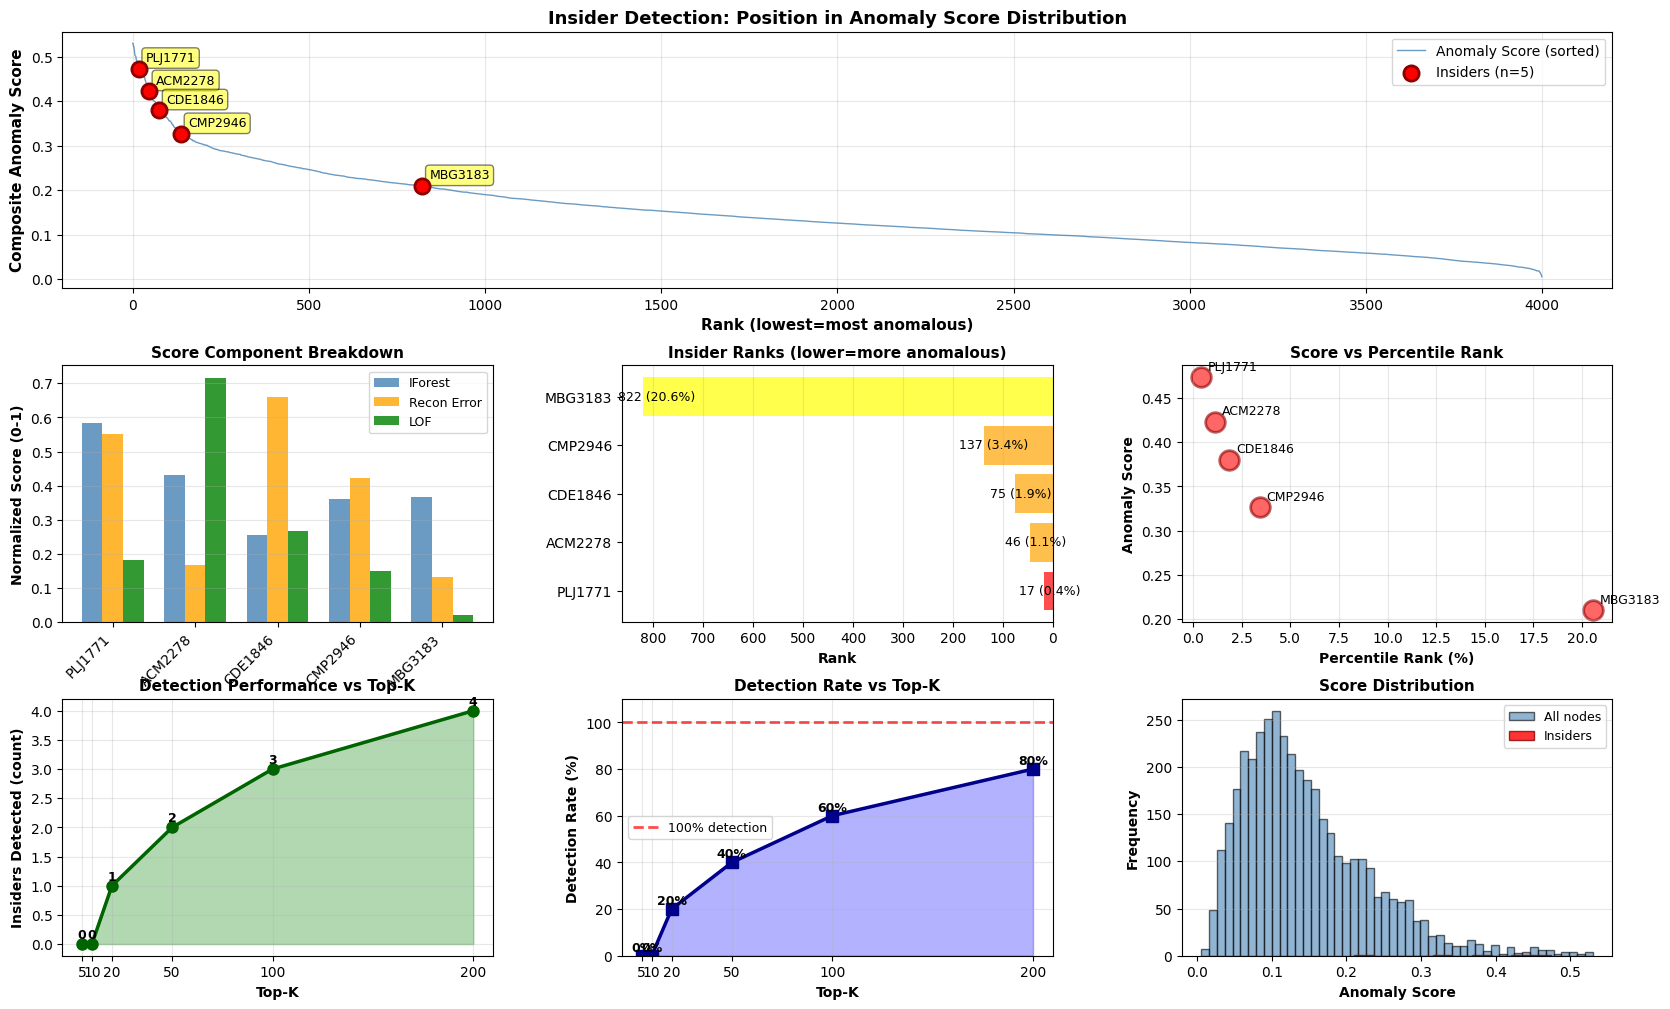

Comprehensive visualization saved to 'results_improved.png'


In [ ]:

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)


ax1 = fig.add_subplot(gs[0, :])
sorted_scores = anomaly_scores[sorted_indices]
ax1.plot(sorted_scores, color='steelblue', linewidth=1, label='Anomaly Score (sorted)', alpha=0.8)
ax1.scatter(insider_ranks, insider_scores, color='red', s=120, zorder=5,
           label=f'Insiders (n={len(insider_node_ids)})', edgecolors='darkred', linewidths=2)


for i, (r, s, u) in enumerate(zip(insider_ranks, insider_scores,
                                   df.loc[insider_node_ids, 'user'].values)):
    ax1.annotate(u, (r, s), fontsize=9, xytext=(5, 5), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

ax1.set_xlabel('Rank (lowest=most anomalous)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Composite Anomaly Score', fontsize=11, fontweight='bold')
ax1.set_title('Insider Detection: Position in Anomaly Score Distribution', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(alpha=0.3)


ax2 = fig.add_subplot(gs[1, 0])
insider_labels = ranking_table['user'].values
x_pos = np.arange(len(insider_labels))
width = 0.25

ax2.bar(x_pos - width, ranking_table['score_iforest'].values, width, 
        label='IForest', color='steelblue', alpha=0.8)
ax2.bar(x_pos, ranking_table['score_recon'].values, width, 
        label='Recon Error', color='orange', alpha=0.8)
ax2.bar(x_pos + width, ranking_table['score_lof'].values, width, 
        label='LOF', color='green', alpha=0.8)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(insider_labels, rotation=45, ha='right')
ax2.set_ylabel('Normalized Score (0-1)', fontsize=10, fontweight='bold')
ax2.set_title('Score Component Breakdown', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, axis='y')


ax3 = fig.add_subplot(gs[1, 1])
colors_rank = ['red' if r < len(anomaly_scores) * 0.01 else 'orange' if r < len(anomaly_scores) * 0.05 else 'yellow'
               for r in ranking_table['rank'].values]
bars = ax3.barh(range(len(insider_labels)), ranking_table['rank'].values, color=colors_rank, alpha=0.7)
ax3.set_yticks(range(len(insider_labels)))
ax3.set_yticklabels(insider_labels)
ax3.set_xlabel('Rank', fontsize=10, fontweight='bold')
ax3.set_title('Insider Ranks (lower=more anomalous)', fontsize=11, fontweight='bold')
ax3.invert_xaxis()
ax3.grid(alpha=0.3, axis='x')

# Add rank values
for i, (v, label) in enumerate(zip(ranking_table['rank'].values, ranking_table['percentile_top'].values)):
    ax3.text(v + 50, i, f'{v} ({label:.1f}%)', va='center', fontsize=9)


ax4 = fig.add_subplot(gs[1, 2])
ax4.scatter(ranking_table['percentile_top'].values, ranking_table['anomaly_score'].values,
           s=200, alpha=0.6, color='red', edgecolors='darkred', linewidths=2)
for i, u in enumerate(insider_labels):
    ax4.annotate(u, (ranking_table['percentile_top'].values[i], ranking_table['anomaly_score'].values[i]),
                fontsize=9, xytext=(5, 5), textcoords='offset points')
ax4.set_xlabel('Percentile Rank (%)', fontsize=10, fontweight='bold')
ax4.set_ylabel('Anomaly Score', fontsize=10, fontweight='bold')
ax4.set_title('Score vs Percentile Rank', fontsize=11, fontweight='bold')
ax4.grid(alpha=0.3)


ax5 = fig.add_subplot(gs[2, 0])
k_values = list(detection_results.keys())
detection_counts = list(detection_results.values())
detection_pct = [100 * c / len(insider_node_ids) for c in detection_counts]
ax5.plot(k_values, detection_counts, marker='o', color='darkgreen', linewidth=2.5, markersize=8)
ax5.fill_between(k_values, detection_counts, alpha=0.3, color='green')
for k, d in zip(k_values, detection_counts):
    ax5.text(k, d + 0.1, f'{d}', ha='center', fontsize=9, fontweight='bold')
ax5.set_xlabel('Top-K', fontsize=10, fontweight='bold')
ax5.set_ylabel('Insiders Detected (count)', fontsize=10, fontweight='bold')
ax5.set_title('Detection Performance vs Top-K', fontsize=11, fontweight='bold')
ax5.set_xticks(k_values)
ax5.grid(alpha=0.3)


ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(k_values, detection_pct, marker='s', color='darkblue', linewidth=2.5, markersize=8)
ax6.fill_between(k_values, detection_pct, alpha=0.3, color='blue')
ax6.axhline(y=100, color='red', linestyle='--', linewidth=2, alpha=0.7, label='100% detection')
for k, p in zip(k_values, detection_pct):
    ax6.text(k, p + 2, f'{p:.0f}%', ha='center', fontsize=9, fontweight='bold')
ax6.set_xlabel('Top-K', fontsize=10, fontweight='bold')
ax6.set_ylabel('Detection Rate (%)', fontsize=10, fontweight='bold')
ax6.set_title('Detection Rate vs Top-K', fontsize=11, fontweight='bold')
ax6.set_xticks(k_values)
ax6.set_ylim([0, 110])
ax6.legend(fontsize=9)
ax6.grid(alpha=0.3)


ax7 = fig.add_subplot(gs[2, 2])
ax7.hist(anomaly_scores, bins=50, alpha=0.6, color='steelblue', label='All nodes', edgecolor='black')
ax7.hist(insider_scores, bins=10, alpha=0.8, color='red', label='Insiders', edgecolor='darkred')
ax7.set_xlabel('Anomaly Score', fontsize=10, fontweight='bold')
ax7.set_ylabel('Frequency', fontsize=10, fontweight='bold')
ax7.set_title('Score Distribution', fontsize=11, fontweight='bold')
ax7.legend(fontsize=9)
ax7.grid(alpha=0.3, axis='y')


plt.show()
print("Comprehensive visualization saved to 'results_improved.png'")